<a href="https://colab.research.google.com/github/brsi-vit/Machine-Learning-Bootcamp/blob/main/Feature_Transformation_and_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Feature Transformation

In [ ]:
data = {
'City': ['Chennai', 'Bangalore', 'Vellore', 'Chennai', 'Bangalore'],
'Size': ['Small', 'Large', 'Medium', 'Large', 'Small'],
'Salary': [60000, 90000, 55000, 70000, 85000],
'Age': [25, 35, 22, 30, 28],
'Score': [88, 72, 91, 79, 65]
}
df = pd.DataFrame(data)
print(df)
print(df.dtypes)

        City    Size  Salary  Age  Score
0    Chennai   Small   60000   25     88
1  Bangalore   Large   90000   35     72
2    Vellore  Medium   55000   22     91
3    Chennai   Large   70000   30     79
4  Bangalore   Small   85000   28     65
City      object
Size      object
Salary     int64
Age        int64
Score      int64
dtype: object


## Polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

x_num = df[['Age', 'Score']]
poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x_num)
poly_df = pd.DataFrame(x_poly, columns=poly.get_feature_names_out(['Age', 'Score']))
print(poly_df)

     1   Age  Score   Age^2  Age Score  Score^2    Age^3  Age^2 Score  \
0  1.0  25.0   88.0   625.0     2200.0   7744.0  15625.0      55000.0   
1  1.0  35.0   72.0  1225.0     2520.0   5184.0  42875.0      88200.0   
2  1.0  22.0   91.0   484.0     2002.0   8281.0  10648.0      44044.0   
3  1.0  30.0   79.0   900.0     2370.0   6241.0  27000.0      71100.0   
4  1.0  28.0   65.0   784.0     1820.0   4225.0  21952.0      50960.0   

   Age Score^2   Score^3  
0     193600.0  681472.0  
1     181440.0  373248.0  
2     182182.0  753571.0  
3     187230.0  493039.0  
4     118300.0  274625.0  


## Interaction Features

In [ ]:
df['Age_x_Score'] = df['Age'] * df['Score']
print(df[['Age', 'Score', 'Age_x_Score']])

   Age  Score  Age_x_Score
0   25     88         2200
1   35     72         2520
2   22     91         2002
3   30     79         2370
4   28     65         1820


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
x_interact = interact.fit_transform(df[['Age', 'Score']])
print(pd.DataFrame(x_interact, columns=interact.get_feature_names_out(['Age', 'Score'])))

    Age  Score  Age Score
0  25.0   88.0     2200.0
1  35.0   72.0     2520.0
2  22.0   91.0     2002.0
3  30.0   79.0     2370.0
4  28.0   65.0     1820.0


## Log Transformations

In [ ]:
df['Salary_log'] = np.log(df['Salary'])
print(df[['Salary', 'Salary_log']])

   Salary  Salary_log
0   60000   11.002100
1   90000   11.407565
2   55000   10.915088
3   70000   11.156251
4   85000   11.350407


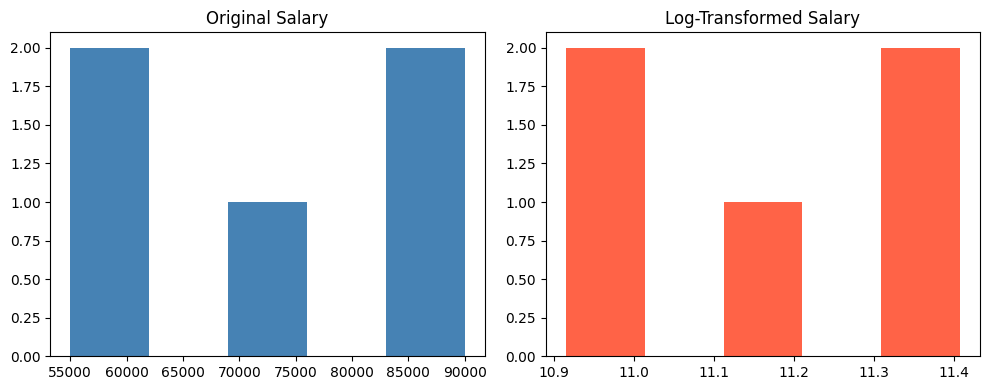

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['Salary'], bins=5, color='steelblue')
axes[0].set_title('Original Salary')
axes[1].hist(df['Salary_log'], bins=5, color='tomato')
axes[1].set_title('Log-Transformed Salary')
plt.tight_layout()
plt.show()

## Square Root & Cube Root Transformation

In [ ]:
df['Salary_sqrt'] = np.sqrt(df['Salary'])
df['Salary_cbrt'] = np.cbrt(df['Salary'])
print(df[['Salary', 'Salary_sqrt', 'Salary_cbrt']])

   Salary  Salary_sqrt  Salary_cbrt
0   60000   244.948974    39.148676
1   90000   300.000000    44.814047
2   55000   234.520788    38.029525
3   70000   264.575131    41.212853
4   85000   291.547595    43.968297


## Exponential Transformation

In [ ]:
small_vals = np.array([1, 2, 3, 4, 5])
exp_vals = np.exp(small_vals)
print('Original: ', small_vals)
print('Exponential: ', exp_vals)

Original:  [1 2 3 4 5]
Exponential:  [  2.71828183   7.3890561   20.08553692  54.59815003 148.4131591 ]


## Inverse Transformation

In [ ]:
df['Salary_inv'] = 1 / df['Salary']
print(df[['Salary', 'Salary_inv']])

   Salary  Salary_inv
0   60000    0.000017
1   90000    0.000011
2   55000    0.000018
3   70000    0.000014
4   85000    0.000012


# Categorical Data Encoding

## Label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['City_label'] = le.fit_transform(df['City'])
print(df[['City', 'City_label']])

        City  City_label
0    Chennai           1
1  Bangalore           0
2    Vellore           2
3    Chennai           1
4  Bangalore           0


## One Hot Encoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
city_encoded = ohe.fit_transform(df[['City']])
city_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(['City']))
print(city_df)

   City_Bangalore  City_Chennai  City_Vellore
0             0.0           1.0           0.0
1             1.0           0.0           0.0
2             0.0           0.0           1.0
3             0.0           1.0           0.0
4             1.0           0.0           0.0


## Ordinal Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
df['Size_ordinal'] = oe.fit_transform(df[['Size']])
print(df[['Size', 'Size_ordinal']])

     Size  Size_ordinal
0   Small           1.0
1   Large           2.0
2  Medium           0.0
3   Large           2.0
4   Small           1.0


## Binary Encoding

In [ ]:
#!pip install category_encoders
import category_encoders as ce

be = ce.BinaryEncoder(cols=['City'])
df_binary = be.fit_transform(df)
print(df_binary.filter(like='City'))

   City_0  City_1  City_label
0       0       1           1
1       1       0           0
2       1       1           2
3       0       1           1
4       1       0           0


## Hash Encoding

In [ ]:
he = ce.HashingEncoder(cols=['City'], n_components=4)
df_hash = he.fit_transform(df)
print(df_hash.filter(like='col_'))

   col_0  col_1  col_2  col_3
0      0      0      1      0
1      1      0      0      0
2      0      0      0      1
3      0      0      1      0
4      1      0      0      0


## Target Encoding

In [ ]:
te = ce.TargetEncoder(cols=['City'])
df['City_target_encoded'] = te.fit_transform(df['City'], df['Salary'])
print(df[['City', 'Salary', 'City_target_encoded']])

        City  Salary  City_target_encoded
0    Chennai   60000         71007.042546
1  Bangalore   90000         74198.691506
2    Vellore   55000         69788.155936
3    Chennai   70000         71007.042546
4  Bangalore   85000         74198.691506


# Feature Scaling

In [ ]:
scale_data = pd.DataFrame({
'Age': [25, 35, 22, 30, 28],
'Salary': [60000, 90000, 55000, 70000, 85000],
'Score': [88, 72, 91, 79, 65]
})
print(scale_data)

   Age  Salary  Score
0   25   60000     88
1   35   90000     72
2   22   55000     91
3   30   70000     79
4   28   85000     65


## Min-Max Scaling (Normalization)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(scale_data)
print(pd.DataFrame(scaled, columns=scale_data.columns))

        Age    Salary     Score
0  0.230769  0.142857  0.884615
1  1.000000  1.000000  0.269231
2  0.000000  0.000000  1.000000
3  0.615385  0.428571  0.538462
4  0.461538  0.857143  0.000000


## Standard Scaling / Standardization (Z-score)

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
standardized = ss.fit_transform(scale_data)
print(pd.DataFrame(standardized, columns=scale_data.columns).round(2))

    Age  Salary  Score
0 -0.68   -0.88   0.93
1  1.58    1.32  -0.72
2 -1.36   -1.25   1.24
3  0.45   -0.15   0.00
4  0.00    0.95  -1.44


## Robust Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
robust_scaled = rs.fit_transform(scale_data)
print(pd.DataFrame(robust_scaled, columns=scale_data.columns).round(2))

   Age  Salary  Score
0 -0.6    -0.4   0.56
1  1.4     0.8  -0.44
2 -1.2    -0.6   0.75
3  0.4     0.0   0.00
4  0.0     0.6  -0.88


## Maximum Absolute Scaling

In [ ]:
from sklearn.preprocessing import MaxAbsScaler

ma = MaxAbsScaler()
maxabs_scaled = ma.fit_transform(scale_data)
print(pd.DataFrame(maxabs_scaled, columns=scale_data.columns).round(2))

    Age  Salary  Score
0  0.71    0.67   0.97
1  1.00    1.00   0.79
2  0.63    0.61   1.00
3  0.86    0.78   0.87
4  0.80    0.94   0.71
